In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [2]:
# ══════════════════════════════════════════════════════════════════════
# Paths
# ══════════════════════════════════════════════════════════════════════
DATA_DIR    = "../Full_Covariance/DATA"
NN_DIR      = "../Full_Covariance/RESULTS_NN"
PINN_DIR    = "../Full_Covariance/RESULTS_PINN"
OUT_DIR     = "./"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# ══════════════════════════════════════════════════════════════════════
# Load data
# ══════════════════════════════════════════════════════════════════════
z_true = np.loadtxt(os.path.join(DATA_DIR, "z_true.csv"), delimiter=",")
d_obs  = np.loadtxt(os.path.join(DATA_DIR, "d_obs.csv"), delimiter=",")
z_MAP  = np.loadtxt(os.path.join(DATA_DIR, "z_MAP.csv"), delimiter=",")

# Noiseless forward response G @ z_true for Fig 1
G_path = os.path.join(DATA_DIR, "G.csv")
if os.path.exists(G_path):
    G_mat   = np.loadtxt(G_path, delimiter=",")
    Gz_true = G_mat @ z_true
else:
    G_mat   = None
    Gz_true = None

# NN and PINN CSVs
nn_pred    = pd.read_csv(os.path.join(NN_DIR, "wing_predictions.csv"))
nn_metrics = pd.read_csv(os.path.join(NN_DIR, "wing_metrics.csv"))
nn_hist    = pd.read_csv(os.path.join(NN_DIR, "wing_histories.csv"))

pinn_pred    = pd.read_csv(os.path.join(PINN_DIR, "wing_pinn_predictions.csv"))
pinn_metrics = pd.read_csv(os.path.join(PINN_DIR, "wing_pinn_metrics.csv"))
pinn_hist    = pd.read_csv(os.path.join(PINN_DIR, "wing_pinn_histories.csv"))

In [4]:
# ══════════════════════════════════════════════════════════════════════
# Problem parameters
# ══════════════════════════════════════════════════════════════════════
n = 50
m = 20
t = np.linspace(0, 1, n)
s = np.linspace(0, 1, m)

In [5]:
# ══════════════════════════════════════════════════════════════════════
# Global matplotlib settings
# ══════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family":          "serif",
    "font.serif":           ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset":     "stix",

    # Larger text for printed paper
    "axes.labelsize":       20,
    "axes.titlesize":       20,
    "xtick.labelsize":      17,
    "ytick.labelsize":      17,
    "legend.fontsize":      15,

    # Legend styling
    "legend.framealpha":    0.95,
    "legend.edgecolor":     "0.7",

    # Tick styling
    "xtick.direction":      "in",
    "ytick.direction":      "in",
    "xtick.major.size":     7,
    "ytick.major.size":     7,
    "xtick.minor.size":     4,
    "ytick.minor.size":     4,
    "xtick.major.width":    1.4,
    "ytick.major.width":    1.4,
    "xtick.minor.width":    1.1,
    "ytick.minor.width":    1.1,

    # Axis lines
    "axes.linewidth":       1.4,

    # Remove clutter
    "axes.spines.top":      False,
    "axes.spines.right":    False,

    # Resolution
    "figure.dpi":           300,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.05,
})

# ══════════════════════════════════════════════════════════════════════
# Line widths and marker sizes for print visibility
# ══════════════════════════════════════════════════════════════════════
LW_TRUE   = 3.8
LW_NN     = 3.0
LW_MAP    = 2.8
LW_MEAN   = 2.6
LW_REF    = 2.6
LW_BARREF = 2.4

MS_DATA   = 10
MEW_DATA  = 2.0

SUBPLOT_TITLE_SIZE = 17
SUPTITLE_SIZE      = 16
LEGEND_SIZE        = 12

# ── Colour palette ────────────────────────────────────────────────────
PRIOR_COLOR = {
    "Gaussian": "#D4A017",
    "Laplace":  "#8B4513",
    "TV":       "#4B0082",
    "Uniform":  "#2E8B57",
}
ARCH_COLOR = {
    "MLP":                  "#E63946",
    "CNN":                  "#1D7FE8",
    "DeepONet_MLP_Fourier": "#2DC653",
}
ARCH_LABEL = {
    "MLP":                  "MLP",
    "CNN":                  "CNN",
    "DeepONet_MLP_Fourier": "DeepONet",
}
SAMPLE_MEAN_COLOR = "#1f77b4"
SAMPLE_MEAN_DASH  = (0, (4, 2))

PRIORS = ["Gaussian", "Laplace", "TV", "Uniform"]
ARCHS  = ["MLP", "CNN", "DeepONet_MLP_Fourier"]

PRIOR_FILES = {
    "Gaussian": ("z_gaussian.csv", "d_gaussian.csv"),
    "Laplace":  ("z_laplace.csv",  "d_laplace.csv"),
    "TV":       ("z_tv.csv",       "d_tv.csv"),
    "Uniform":  ("z_uniform.csv",  "d_uniform.csv"),
}

In [6]:
# ══════════════════════════════════════════════════════════════════════
# Helper functions
# ══════════════════════════════════════════════════════════════════════
def get_pred(df, prior, model):
    sub = df[(df["prior"] == prior) & (df["model"] == model)].copy()
    if len(sub) == 0:
        return None
    sub = sub.sort_values("t_index")
    return sub["prediction"].values


def get_metric(df, prior, model, metric):
    row = df[(df["prior"] == prior) & (df["model"] == model)]
    return float(row[metric].values[0]) if len(row) else np.nan


def get_history(df, prior, model):
    sub = df[(df["prior"] == prior) & (df["model"] == model)].copy()
    return sub.sort_values("epoch")


def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        direction="in",
        which="both",
        top=False,
        right=False,
        width=1.3,
        pad=6,
    )


def savefig(fig, name):
    fig.savefig(os.path.join(OUT_DIR, f"{name}.png"))
    print(f"  Saved {name}.png")


def plot_ztrue(ax):
    ax.step(
        t, z_true, "k-",
        lw=LW_TRUE,
        where="mid",
        zorder=10,
        label=r"$m_{\rm true}$",
    )


def plot_map(ax):
    ax.plot(
        t, z_MAP,
        color="#555555",
        lw=LW_MAP,
        ls="--",
        zorder=9,
        label="MAP",
    )


def reference_legend_elements():
    return [
        Line2D(
            [0], [0],
            color="k",
            lw=LW_TRUE,
            ls="-",
            label=r"$z_{\rm true}$",
            drawstyle="steps-mid",
        ),
        Line2D(
            [0], [0],
            color="#555555",
            lw=LW_MAP,
            ls="--",
            label="MAP",
        ),
        Line2D(
            [0], [0],
            color=SAMPLE_MEAN_COLOR,
            lw=LW_MEAN,
            ls=SAMPLE_MEAN_DASH,
            label="Sample Mean",
        ),
    ]


def plot_references(ax, prior):
    Z = np.loadtxt(os.path.join(DATA_DIR, PRIOR_FILES[prior][0]), delimiter=",")
    z_mean_prior = np.mean(Z, axis=0)
    plot_ztrue(ax)
    plot_map(ax)
    ax.plot(
        t, z_mean_prior,
        color=SAMPLE_MEAN_COLOR,
        lw=LW_MEAN,
        ls=SAMPLE_MEAN_DASH,
        zorder=8,
    )

Figure 1 — True model and observed data
  Saved wing_true_model.png


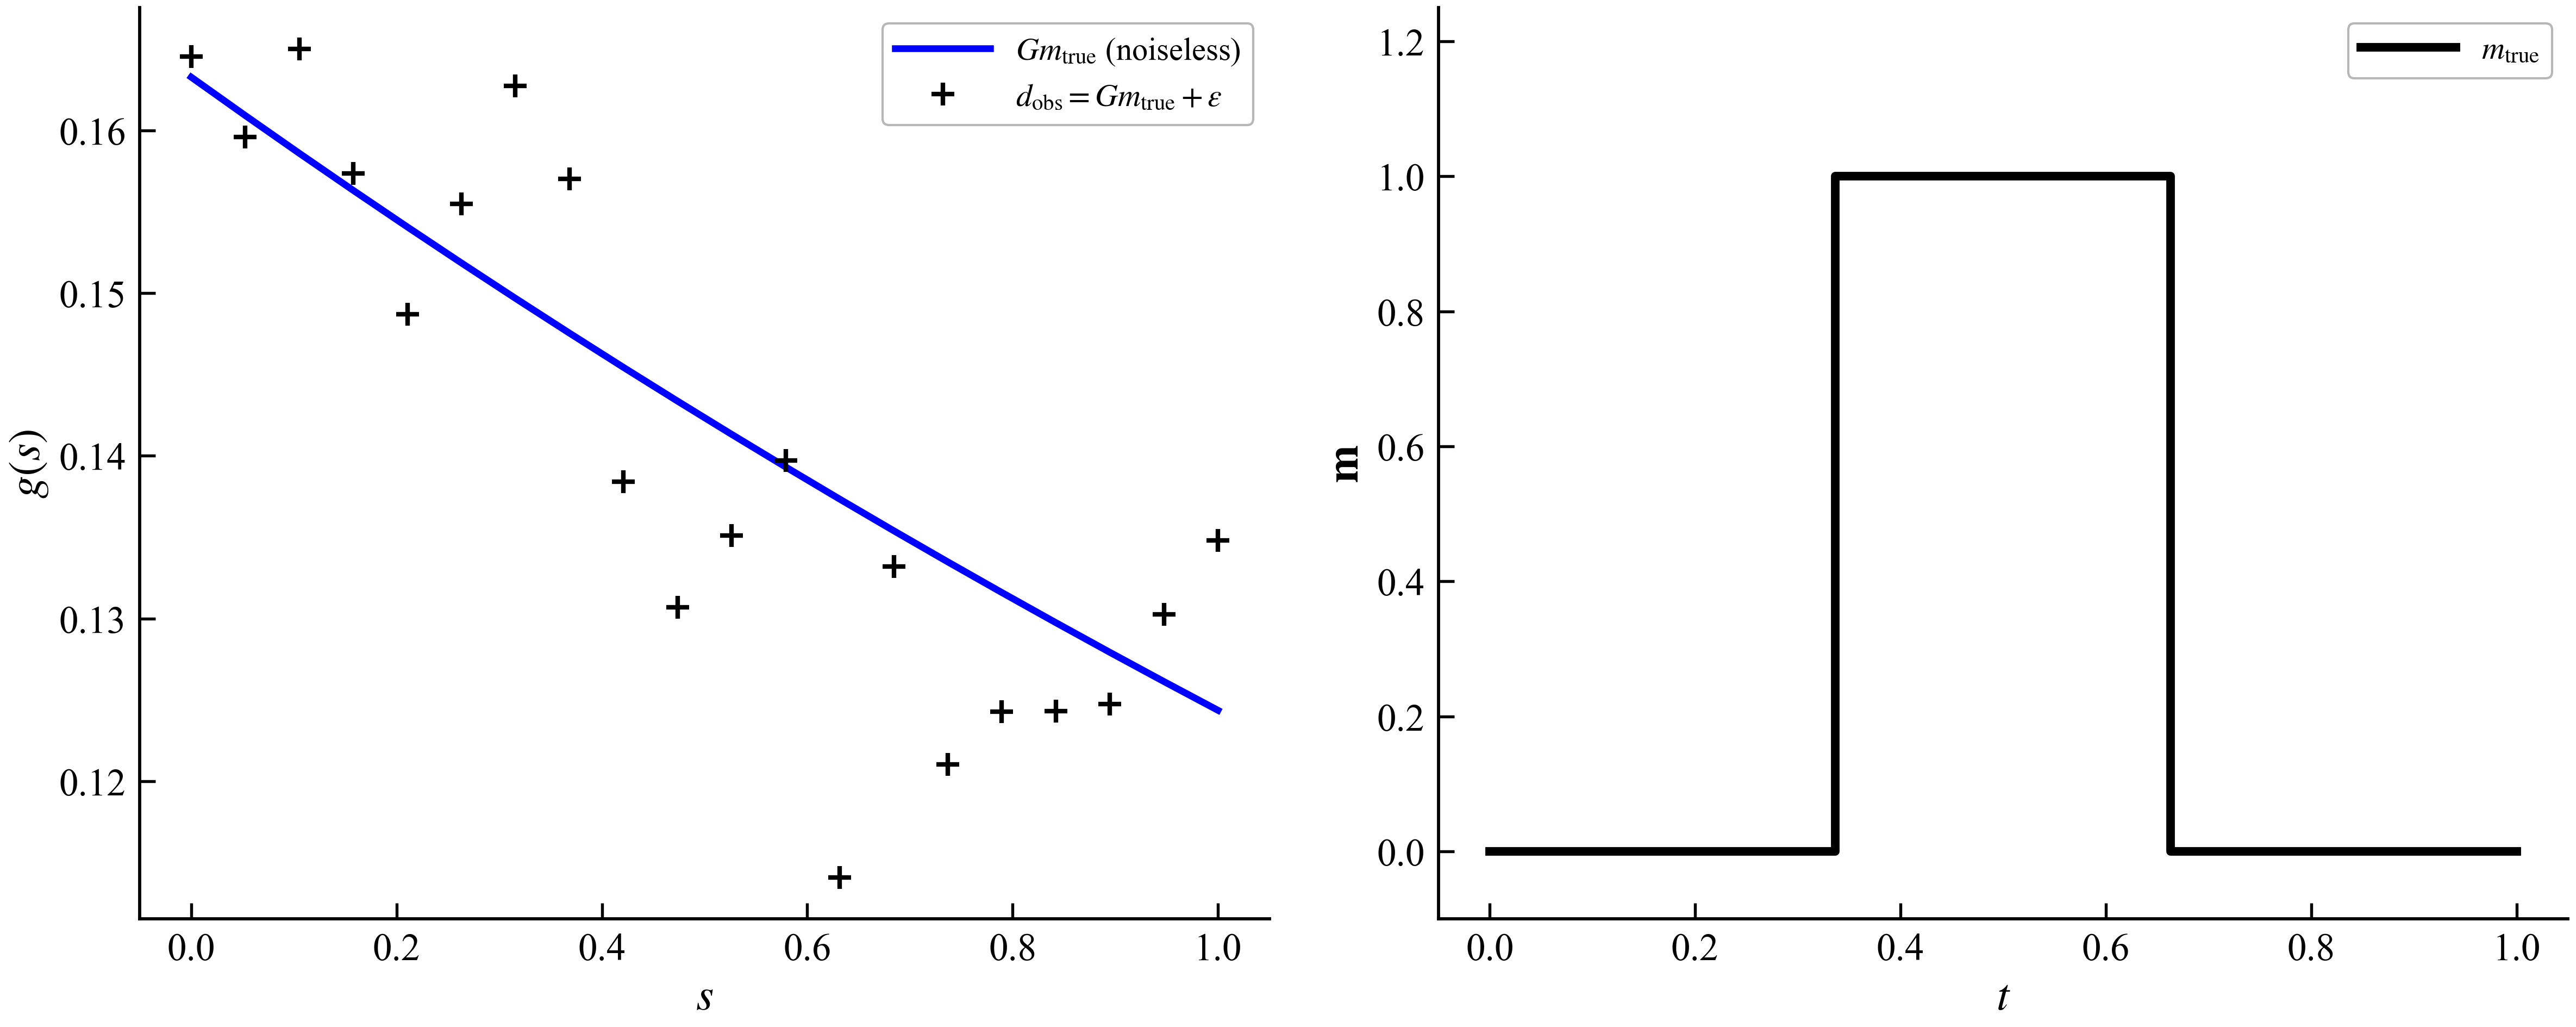

In [7]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — True model and observed data
# ══════════════════════════════════════════════════════════════════════
print("Figure 1 — True model and observed data")

fig = plt.figure(figsize=(16, 6.5))

# Left panel: forward problem
plt.subplot(1, 2, 1)
ax = plt.gca()
if Gz_true is not None:
    ax.plot(
        s, Gz_true, "b-",
        lw=LW_NN,
        label=r"$G m_{\rm true}$ (noiseless)",
        zorder=5,
    )
ax.plot(
    s, d_obs, "k+",
    ms=MS_DATA,
    mew=MEW_DATA,
    label=r"$d_{\rm obs} = G m_{\rm true} + \varepsilon$",
    zorder=6,
)
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$g(s)$")
ax.legend(loc="upper right", fontsize=14, handlelength=3.0, framealpha=0.95)
style_ax(ax)

# Right panel: true solution
plt.subplot(1, 2, 2)
ax = plt.gca()
ax.step(
    t, z_true, "k-",
    lw=LW_TRUE,
    where="mid",
    label=r"$m_{\rm true}$",
)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathbf{m}$")
ax.set_ylim(-0.1, 1.25)
ax.legend(loc="upper right", fontsize=14, handlelength=3.0, framealpha=0.95)
style_ax(ax)

plt.tight_layout(w_pad=2.5)
savefig(fig, "wing_true_model")
plt.show()


Figure 2 — NN all architectures by prior
  Saved wing_NN_all_architectures.png


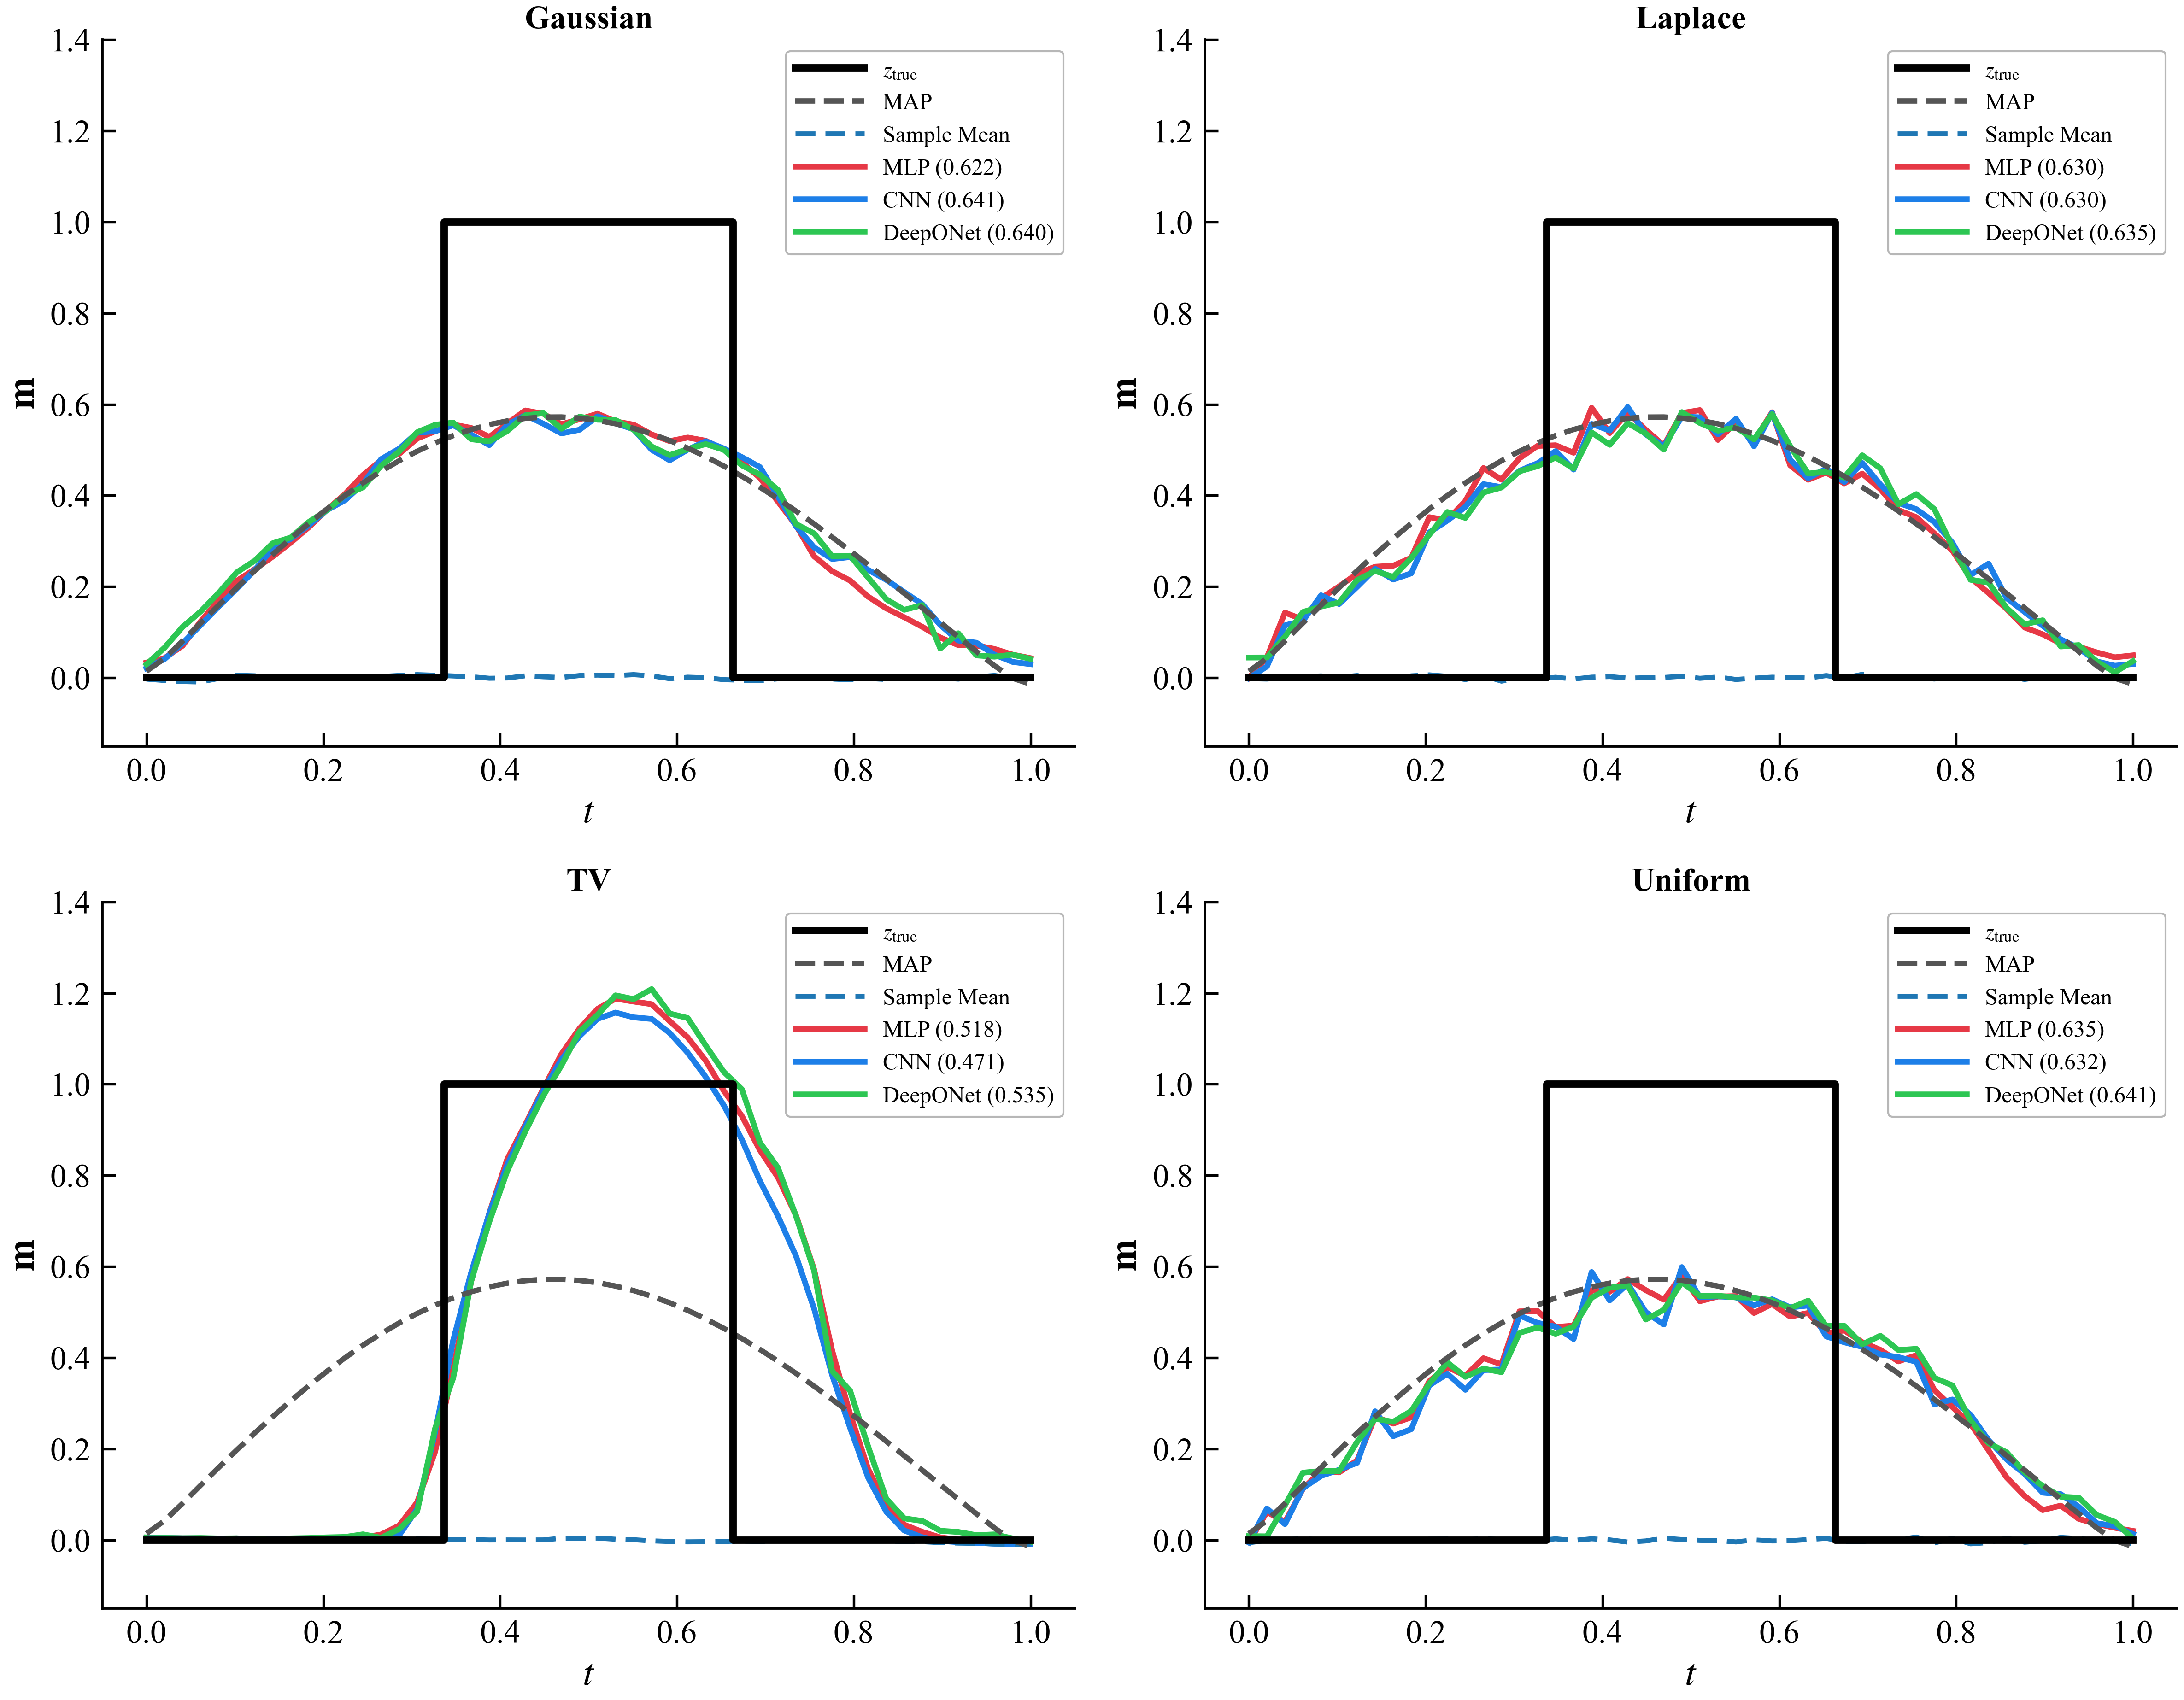

In [8]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — NN predictions: all architectures by prior
# ══════════════════════════════════════════════════════════════════════
print("Figure 2 — NN all architectures by prior")

fig = plt.figure(figsize=(16, 12.5))

for idx, prior in enumerate(PRIORS):
    plt.subplot(2, 2, idx + 1)
    ax = plt.gca()
    plot_references(ax, prior)

    for arch in ARCHS:
        z_pred = get_pred(nn_pred, prior, arch)
        if z_pred is None:
            continue
        rl2 = get_metric(nn_metrics, prior, arch, "Rel_L2")
        rl2_str = f"{rl2:.3f}" if not np.isnan(rl2) else "pending"
        ax.plot(
            t, z_pred,
            color=ARCH_COLOR[arch],
            lw=LW_NN,
            ls="-",
            label=f"{ARCH_LABEL[arch]}",
        )

    ax.set_title(prior, fontweight="bold", fontsize=SUBPLOT_TITLE_SIZE)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\mathbf{m}$")
    ax.set_ylim(-0.15, 1.4)
    style_ax(ax)

    ref_handles = reference_legend_elements()
    arch_handles = [
        Line2D(
            [0], [0],
            color=ARCH_COLOR[a],
            lw=LW_NN,
            ls="-",
            label=f"{ARCH_LABEL[a]} ({get_metric(nn_metrics, prior, a, 'Rel_L2'):.3f})",
        )
        for a in ARCHS
        if get_pred(nn_pred, prior, a) is not None
    ]
    ax.legend(
        handles=ref_handles + arch_handles,
        loc="upper right",
        fontsize=LEGEND_SIZE,
        handlelength=3.0,
        framealpha=0.95,
    )


plt.tight_layout(h_pad=2.0, w_pad=1.8)
savefig(fig, "wing_NN_all_architectures")
plt.show()

Figure 3 — PINN all architectures by prior
  Saved wing_PINN_all_architectures.png


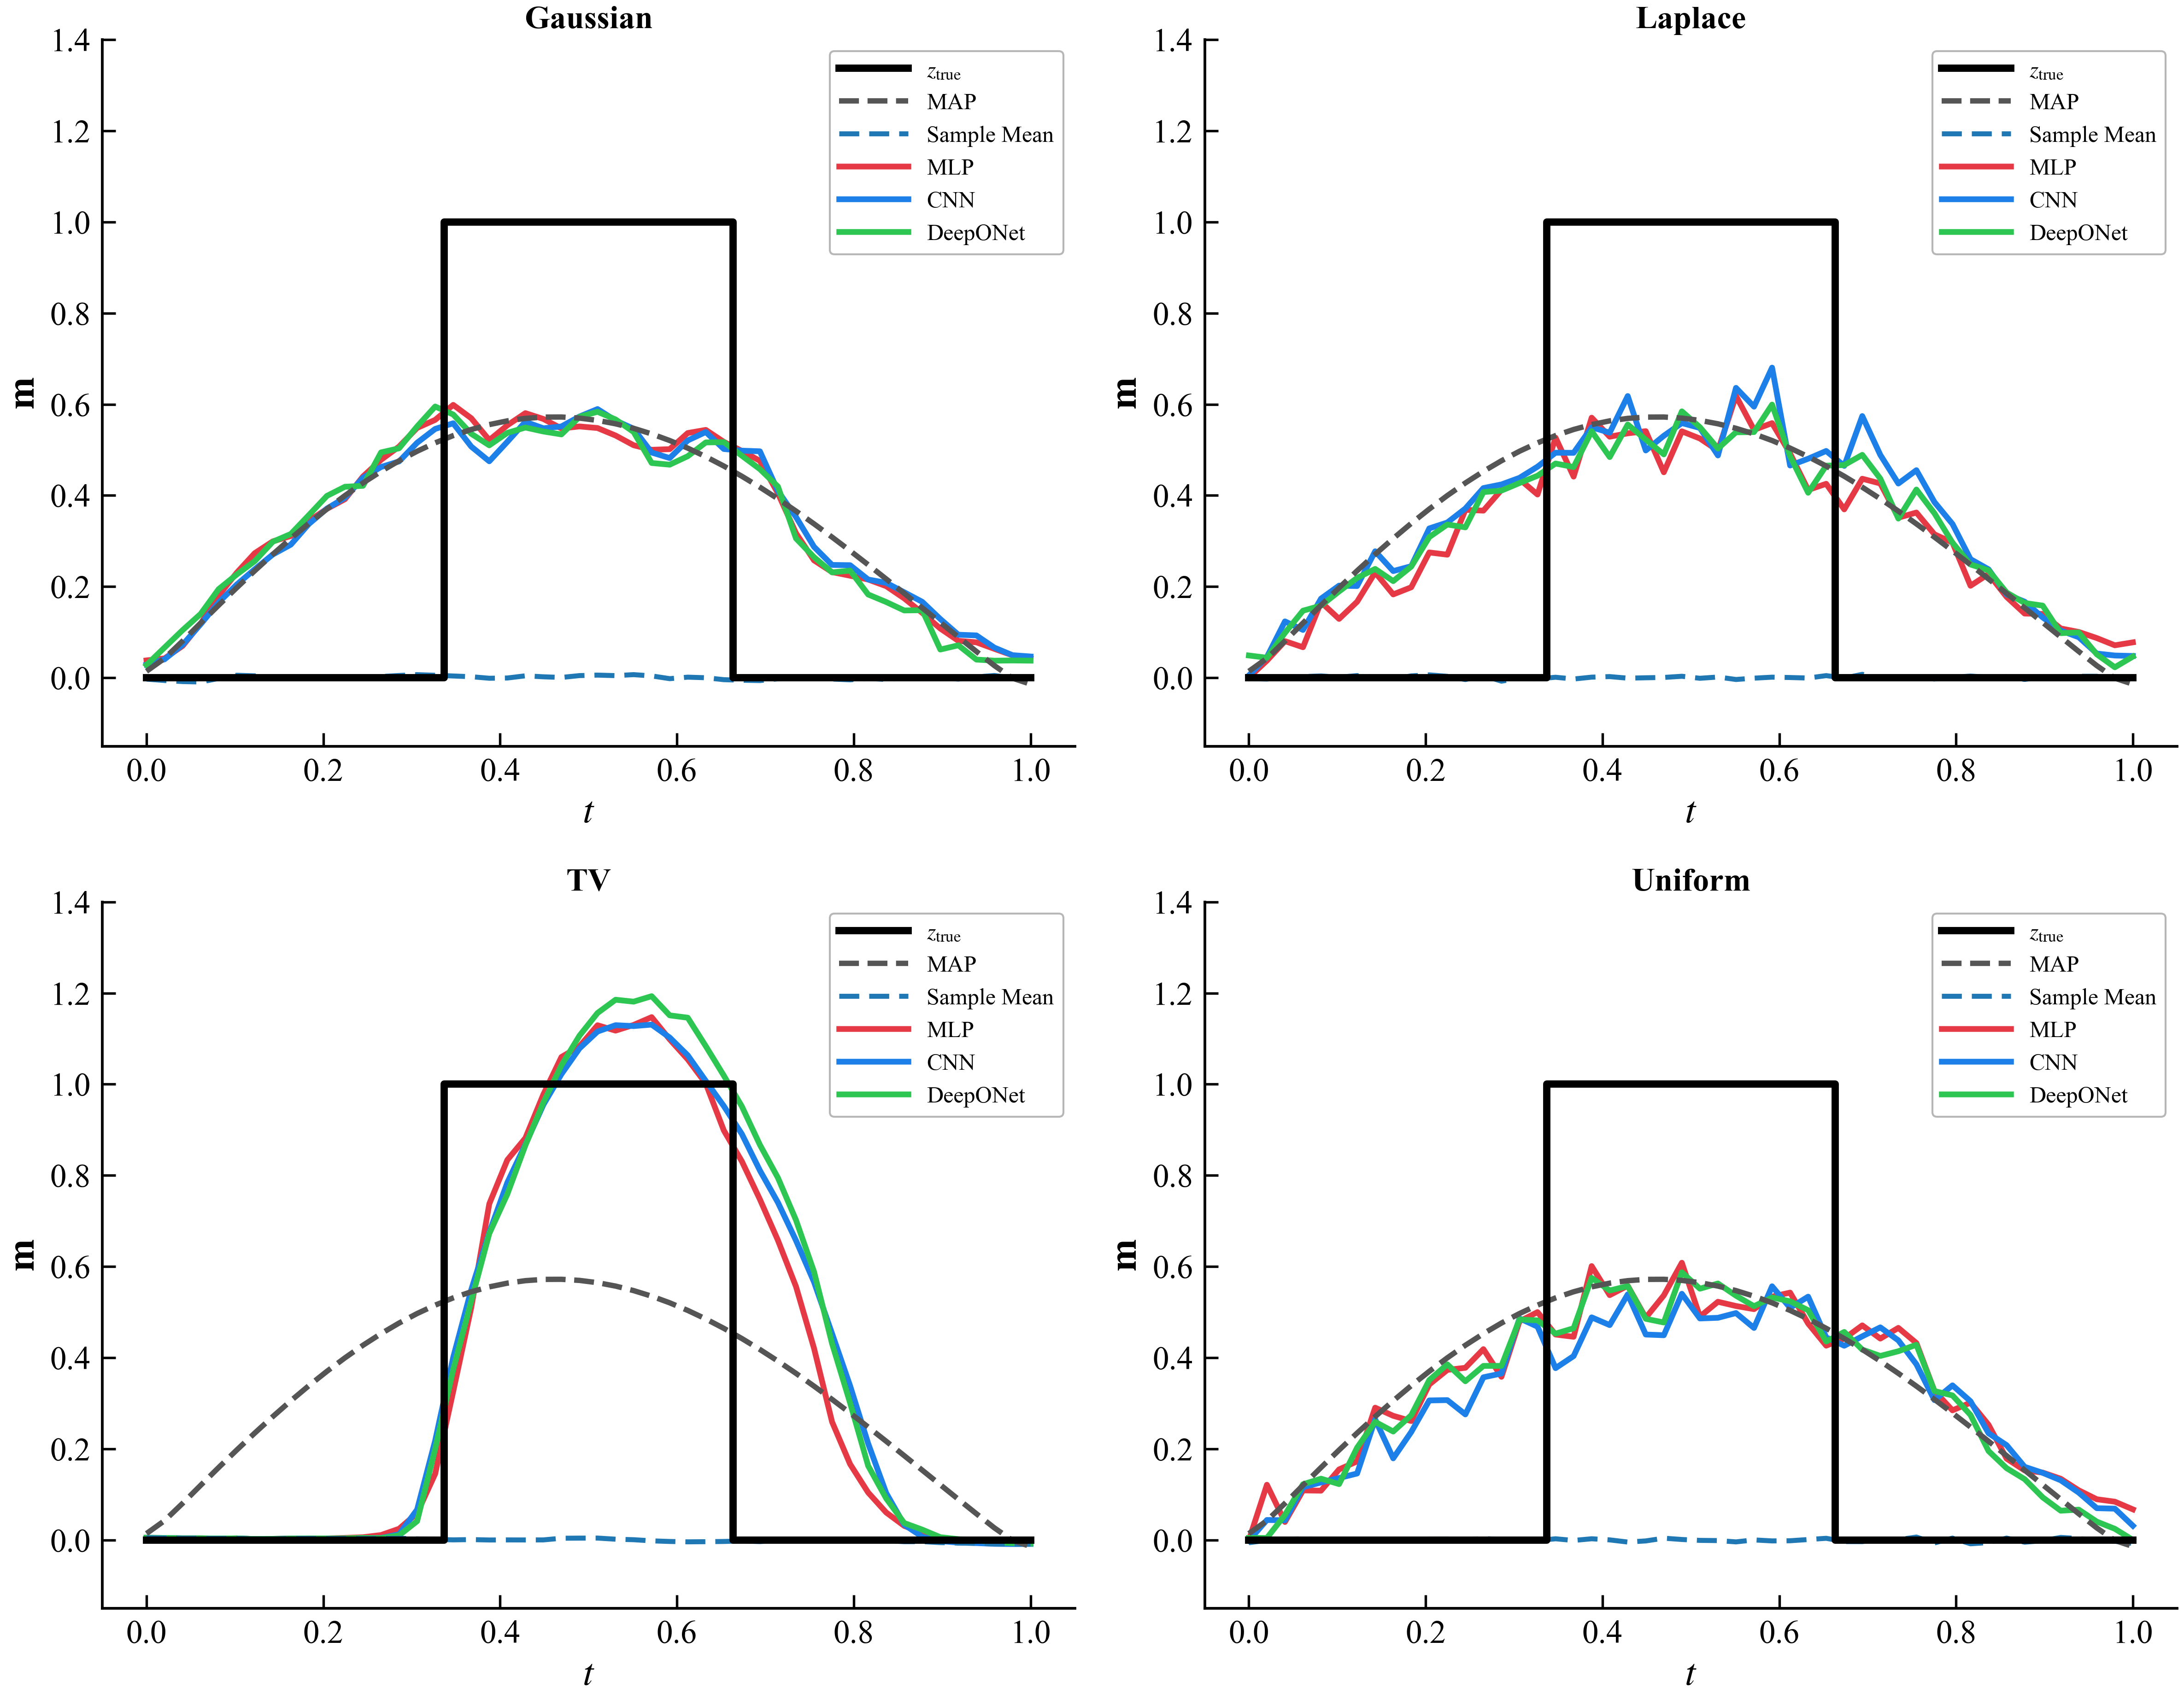

In [9]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — PINN predictions: all architectures by prior
# ══════════════════════════════════════════════════════════════════════
print("Figure 3 — PINN all architectures by prior")

fig = plt.figure(figsize=(16, 12.5))

for idx, prior in enumerate(PRIORS):
    plt.subplot(2, 2, idx + 1)
    ax = plt.gca()
    plot_references(ax, prior)

    for arch in ARCHS:
        z_pred = get_pred(pinn_pred, prior, arch)
        if z_pred is None:
            continue
        rl2 = get_metric(pinn_metrics, prior, arch, "Rel_L2")
        rl2_str = f"{rl2:.3f}" if not np.isnan(rl2) else "pending"
        ax.plot(
            t, z_pred,
            color=ARCH_COLOR[arch],
            lw=LW_NN,
            ls="-",
            label=f"{ARCH_LABEL[arch]} ({rl2_str})",
        )

    ax.set_title(prior, fontweight="bold", fontsize=SUBPLOT_TITLE_SIZE)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\mathbf{m}$")
    ax.set_ylim(-0.15, 1.4)
    style_ax(ax)

    ref_handles = reference_legend_elements()
    arch_handles = [
    Line2D(
        [0], [0],
        color=ARCH_COLOR[a],
        lw=LW_NN,
        ls="-",
        label=f"{ARCH_LABEL[a]}",
    )
    for a in ARCHS
    if get_pred(pinn_pred, prior, a) is not None
]
        
    ax.legend(
        handles=ref_handles + arch_handles,
        loc="upper right",
        fontsize=LEGEND_SIZE,
        handlelength=3.0,
        framealpha=0.95,
    )

plt.tight_layout(h_pad=2.0, w_pad=1.8)
savefig(fig, "wing_PINN_all_architectures")
plt.show()


Figure 4 — Best architecture NN vs PINN by prior
  Saved wing_best_NN_vs_PINN.png


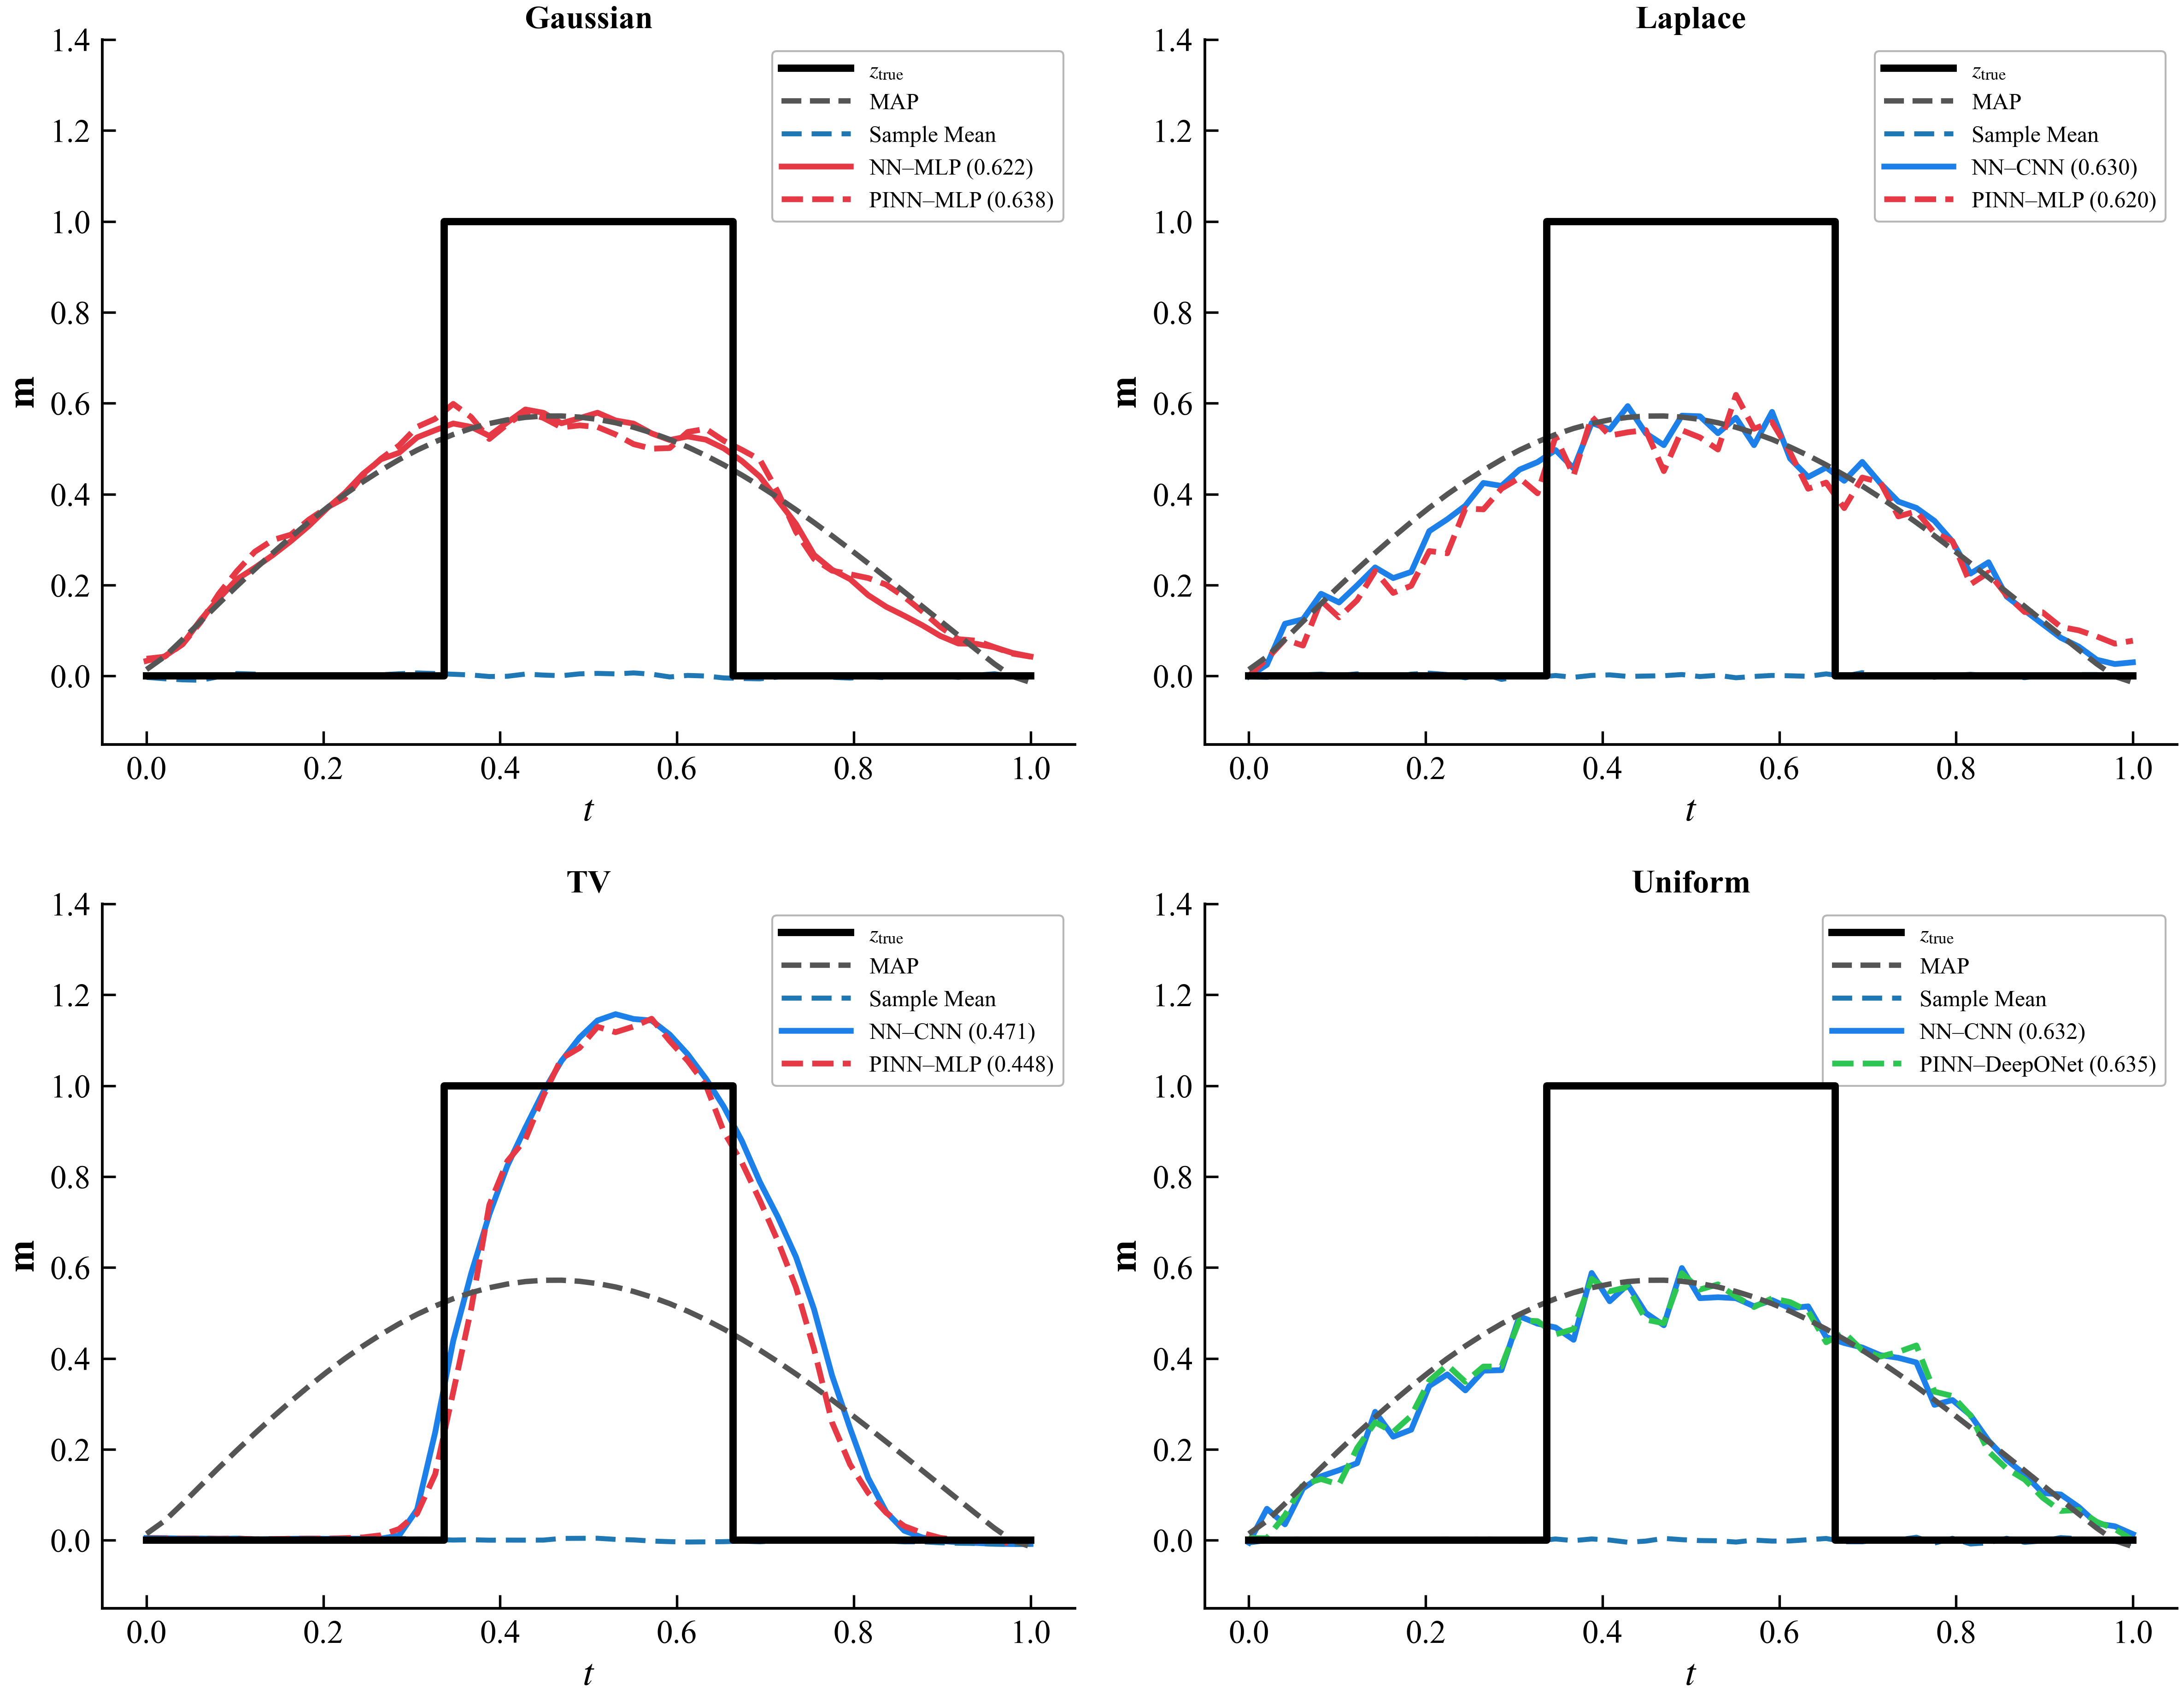

In [10]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 4 — Best architecture: NN vs PINN by prior
# ══════════════════════════════════════════════════════════════════════
print("Figure 4 — Best architecture NN vs PINN by prior")

fig = plt.figure(figsize=(16, 12.5))

for idx, prior in enumerate(PRIORS):
    plt.subplot(2, 2, idx + 1)
    ax = plt.gca()
    plot_references(ax, prior)

    avail_nn = [a for a in ARCHS if get_pred(nn_pred, prior, a) is not None]
    avail_pinn = [a for a in ARCHS if get_pred(pinn_pred, prior, a) is not None]

    nn_rl2 = {a: get_metric(nn_metrics, prior, a, "Rel_L2") for a in avail_nn}
    pinn_rl2 = {a: get_metric(pinn_metrics, prior, a, "Rel_L2") for a in avail_pinn}

    pred_handles = []

    if avail_nn:
        best_nn = min(nn_rl2, key=nn_rl2.get)
        z_nn = get_pred(nn_pred, prior, best_nn)
        ax.plot(
            t, z_nn,
            color=ARCH_COLOR[best_nn],
            lw=LW_NN,
            ls="-",
            label=f"NN–{ARCH_LABEL[best_nn]}",
        )
        pred_handles.append(
            Line2D(
                [0], [0],
                color=ARCH_COLOR[best_nn],
                lw=LW_NN,
                ls="-",
                label=f"NN–{ARCH_LABEL[best_nn]} ({nn_rl2[best_nn]:.3f})",
            )
        )

    if avail_pinn:
        best_pinn = min(pinn_rl2, key=pinn_rl2.get)
        z_pinn = get_pred(pinn_pred, prior, best_pinn)
        ax.plot(
            t, z_pinn,
            color=ARCH_COLOR[best_pinn],
            lw=LW_NN,
            ls="--",
            label=f"PINN–{ARCH_LABEL[best_pinn]}",
        )
        pred_handles.append(
            Line2D(
                [0], [0],
                color=ARCH_COLOR[best_pinn],
                lw=LW_NN,
                ls="--",
                label=f"PINN–{ARCH_LABEL[best_pinn]} ({pinn_rl2[best_pinn]:.3f})",
            )
        )

    ax.set_title(prior, fontweight="bold", fontsize=SUBPLOT_TITLE_SIZE)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\mathbf{m}$")
    ax.set_ylim(-0.15, 1.4)
    style_ax(ax)

    ref_handles = reference_legend_elements()
    ax.legend(
        handles=ref_handles + pred_handles,
        loc="upper right",
        fontsize=LEGEND_SIZE,
        handlelength=3.0,
        framealpha=0.95,
    )

plt.tight_layout(h_pad=2.2, w_pad=1.8)
savefig(fig, "wing_best_NN_vs_PINN")
plt.show()

In [11]:
""" Uploading best Gaussian (uncorrelated NN)from the Constant covariance folder """ 

# Load Constant Covariance NN results directly
CONST_NN_DIR = "../Constant_Covariance/RESULTS_NN"

nn_pred_const = pd.read_csv(
    os.path.join(CONST_NN_DIR, "wing_predictions.csv")
)

nn_metrics_const = pd.read_csv(
    os.path.join(CONST_NN_DIR, "wing_metrics.csv")
)

# Find best Gaussian NN under constant/uncorrelated covariance
prior = "Gaussian"

avail_nn_const = [
    a for a in ARCHS
    if get_pred(nn_pred_const, prior, a) is not None
]

nn_rl2_const = {
    a: get_metric(nn_metrics_const, prior, a, "Rel_L2")
    for a in avail_nn_const
}

best_gaussian_const_arch = min(nn_rl2_const, key=nn_rl2_const.get)

gaussian_uncorr = get_pred(
    nn_pred_const,
    prior,
    best_gaussian_const_arch
)

gaussian_const_rl2 = nn_rl2_const[best_gaussian_const_arch]

print("Best Gaussian uncorrelated NN:", best_gaussian_const_arch)
print("Relative L2:", gaussian_const_rl2)

Best Gaussian uncorrelated NN: MLP
Relative L2: 0.6472068484659432


  Saved wing_best_NN_all_priors.png


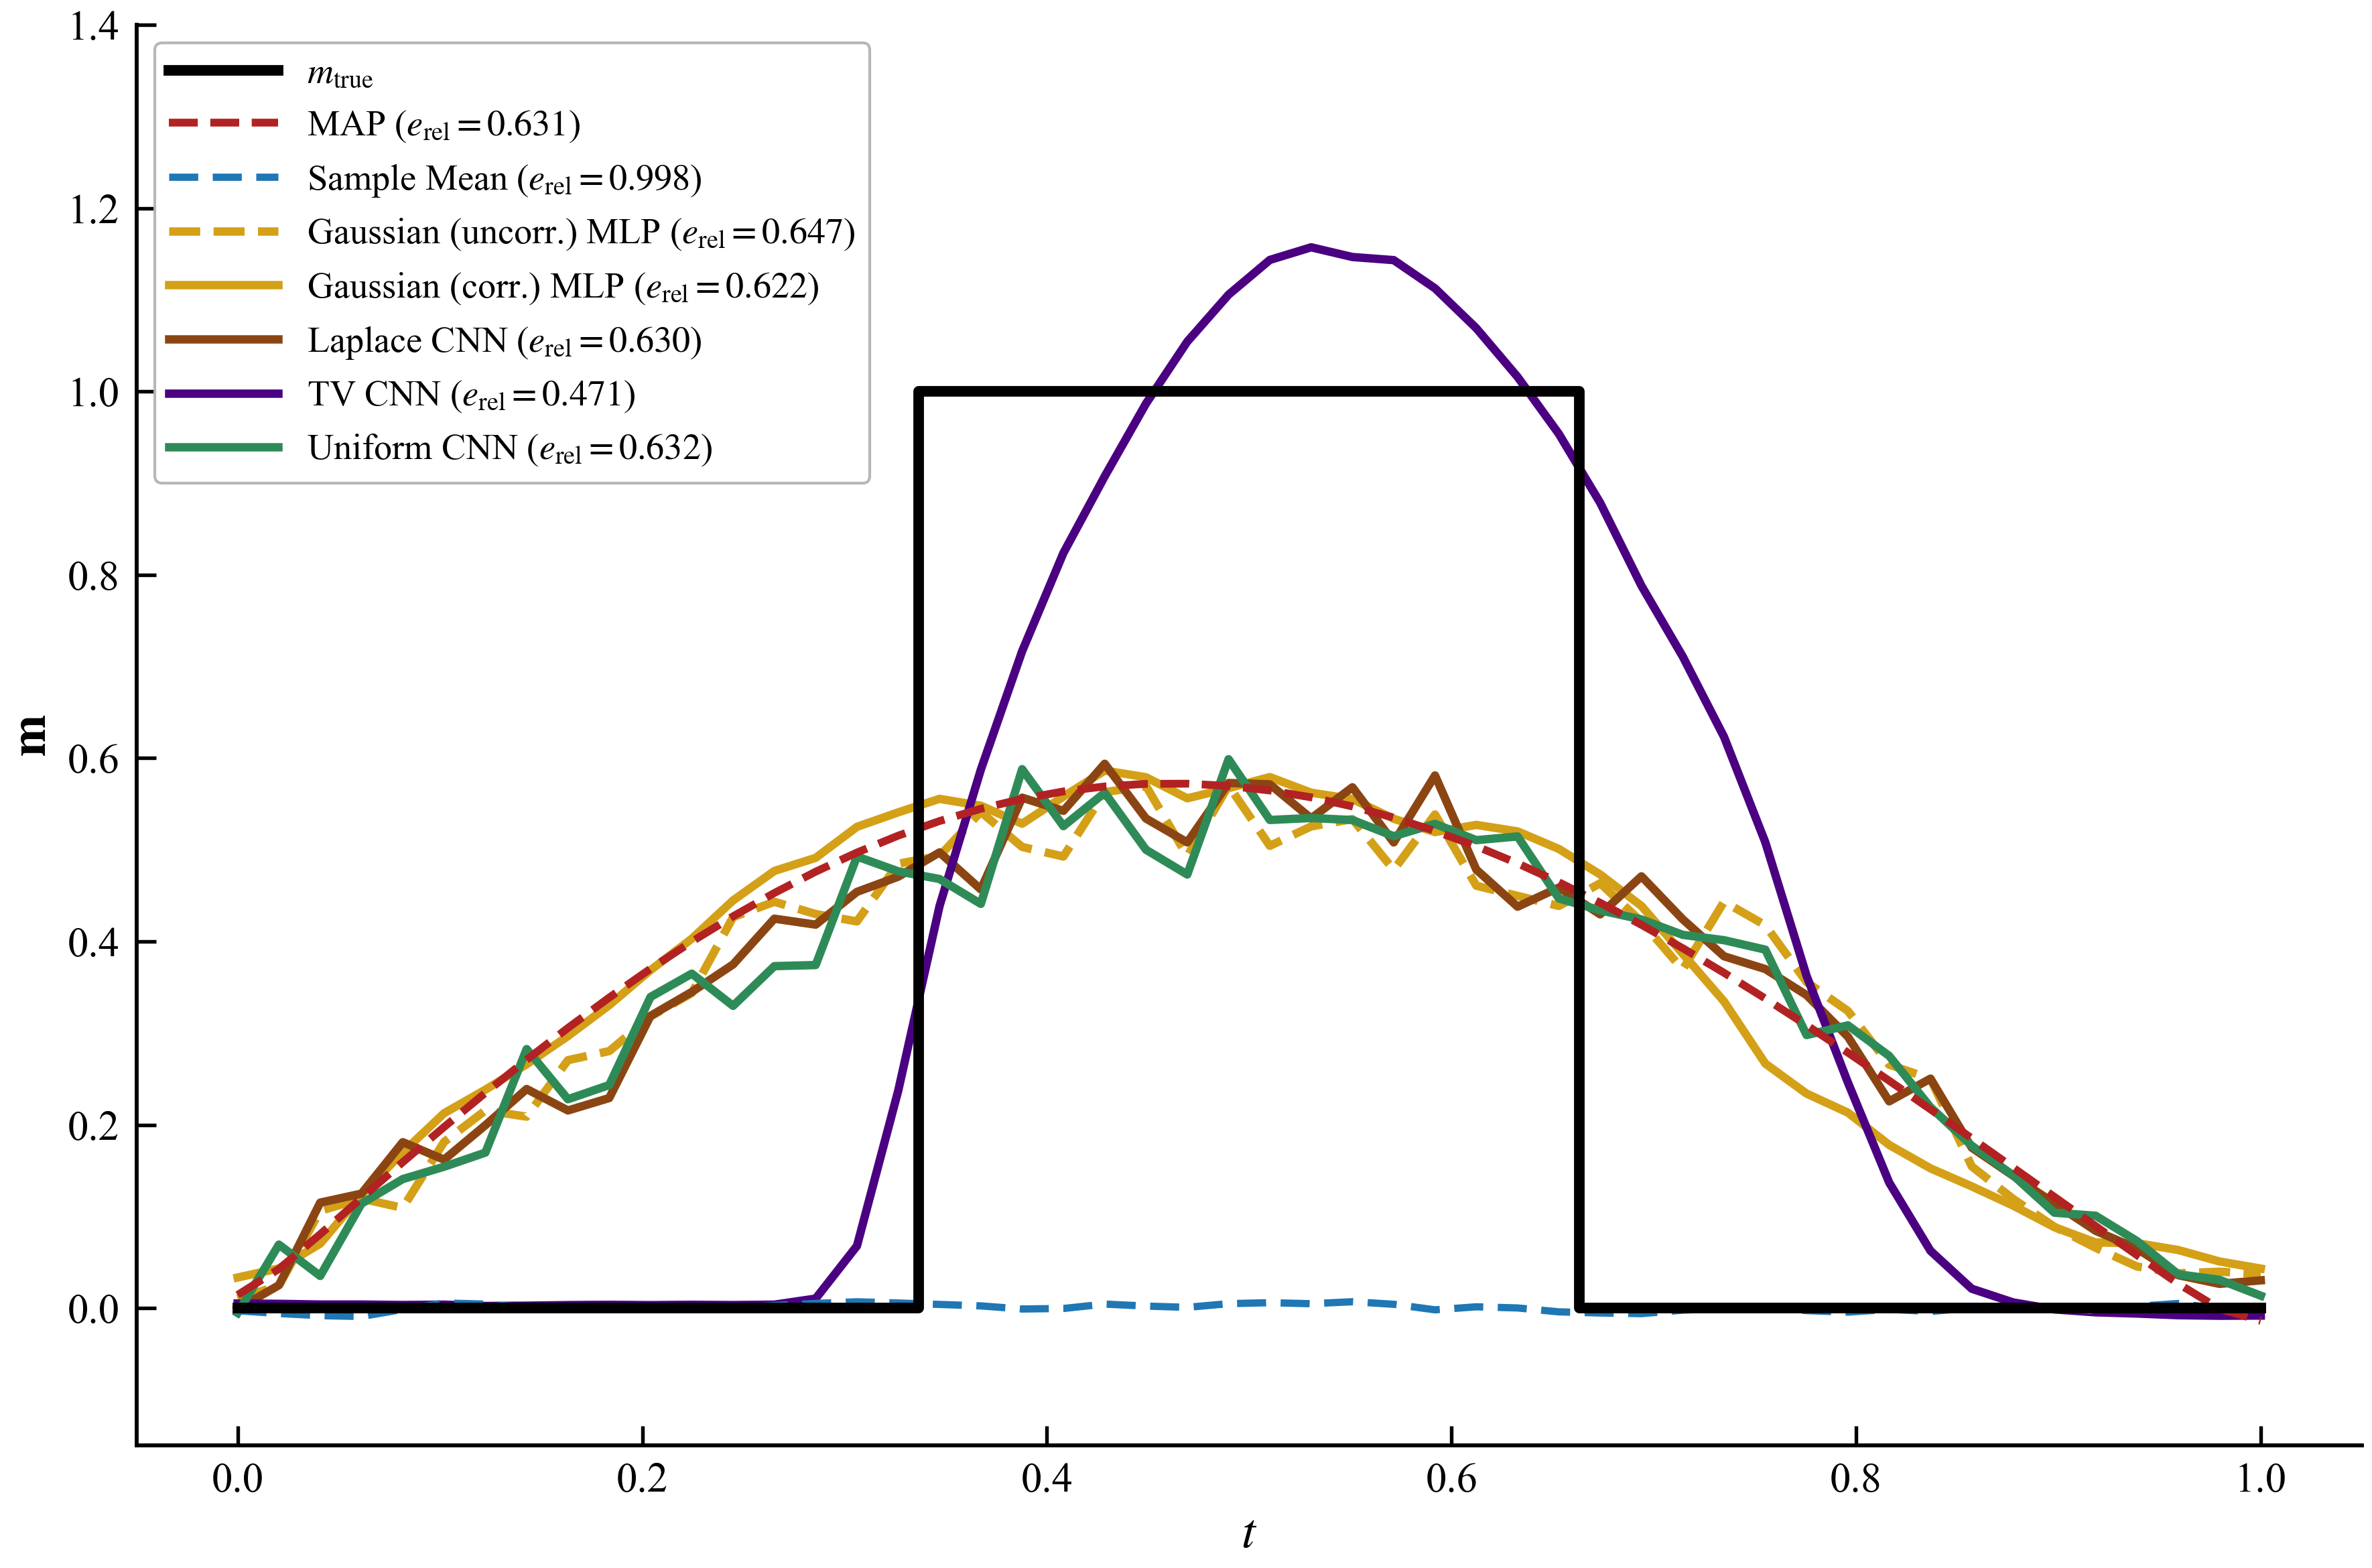

In [12]:
# Load Gaussian uncorrelated best NN prediction
gaussian_const_rl2 = 0.647


# Best NN per prior (correlated covariance) from metrics table
best_nn = {
    "Gaussian": ("MLP", "#D4A017", 0.622),
    "Laplace":  ("CNN", "#8B4513", 0.630),
    "TV":       ("CNN", "#4B0082", 0.471),
    "Uniform":  ("CNN", "#2E8B57", 0.632),
}

# Print-friendly line widths
LW_TRUE = 3.8
LW_MAP  = 2.8
LW_NN   = 3.0
LW_MEAN = 2.6

# Gaussian sample mean
Z_gaussian = np.loadtxt(os.path.join(DATA_DIR, PRIOR_FILES["Gaussian"][0]), delimiter=",")
z_mean_gaussian = np.mean(Z_gaussian, axis=0)
gaussian_sm_rl2 = get_metric(nn_metrics, "Gaussian", "Sample_Mean", "Rel_L2")

fig, ax = plt.subplots(figsize=(12, 8))

# True solution
ax.step(
    t, z_true,
    "k-",
    lw=LW_TRUE,
    where="mid",
    label=r"$m_{\rm true}$",
    zorder=10,
)

# MAP
ax.plot(
    t, z_MAP,
    color="#B22222",
    lw=LW_MAP,
    ls="--",
    label=r"MAP ($e_{\rm rel} = 0.631$)",
    zorder=9,
)

# Gaussian sample mean
ax.plot(
    t, z_mean_gaussian,
    color=SAMPLE_MEAN_COLOR,
    lw=LW_MEAN,
    ls=SAMPLE_MEAN_DASH,
    label=rf"Sample Mean ($e_{{\rm rel}} = {gaussian_sm_rl2:.3f}$)",
    zorder=8,
)


# Gaussian uncorrelated best NN
ax.plot(
    t, gaussian_uncorr,
    color="#D4A017",
    lw=LW_NN,
    ls="--",
    label=rf"Gaussian (uncorr.) MLP ($e_{{\rm rel}} = {gaussian_const_rl2:.3f}$)",
    zorder=6,
)

# Best NN per prior (correlated covariance)
for prior, (arch, color, rl2) in best_nn.items():
    z_pred = get_pred(nn_pred, prior, arch)
    if z_pred is not None:
        if prior == "Gaussian":
            label = rf"{prior} (corr.) {arch} ($e_{{\rm rel}} = {rl2:.3f}$)"
        else:
            label = rf"{prior} {arch} ($e_{{\rm rel}} = {rl2:.3f}$)"
        ax.plot(
            t, z_pred,
            color=color,
            lw=LW_NN,
            label=label,
            zorder=7,
        )



ax.set_xlabel(r"$t$", fontsize=18)
ax.set_ylabel(r"$\mathbf{m}$", fontsize=18)
ax.set_ylim(-0.15, 1.4)
ax.tick_params(axis="both", labelsize=15)
style_ax(ax)
ax.legend(
    loc="upper left",
    fontsize=13,
    framealpha=0.95,
    handlelength=3.0,
)
plt.tight_layout()
savefig(fig, "wing_best_NN_all_priors")
plt.show()

In [13]:
# ══════════════════════════════════════════════════════════════════════
# TABLE 1 — Metrics table
# ══════════════════════════════════════════════════════════════════════
print("Table 1 — Metrics table")

rows_learned = []
rows_reference = []

for prior in PRIORS:
    for arch in ARCHS:
        nn_avail = get_pred(nn_pred, prior, arch) is not None
        pinn_avail = get_pred(pinn_pred, prior, arch) is not None

        if nn_avail:
            rows_learned.append({
                "Prior":   prior,
                "Model":   f"{ARCH_LABEL[arch]} (NN)",
                "Method":  "NN",
                "RMSE":    get_metric(nn_metrics, prior, arch, "RMSE"),
                "Rel_L2":  get_metric(nn_metrics, prior, arch, "Rel_L2"),
            })

        if pinn_avail:
            rows_learned.append({
                "Prior":   prior,
                "Model":   f"{ARCH_LABEL[arch]} (PINN)",
                "Method":  "PINN",
                "RMSE":    get_metric(pinn_metrics, prior, arch, "RMSE"),
                "Rel_L2":  get_metric(pinn_metrics, prior, arch, "Rel_L2"),
            })

    rows_reference.append({
        "Prior":   prior,
        "Model":   "MAP",
        "Method":  "Reference",
        "RMSE":    get_metric(nn_metrics, prior, "MAP", "RMSE"),
        "Rel_L2":  get_metric(nn_metrics, prior, "MAP", "Rel_L2"),
    })
    rows_reference.append({
        "Prior":   prior,
        "Model":   "Sample Mean",
        "Method":  "Reference",
        "RMSE":    get_metric(nn_metrics, prior, "Sample_Mean", "RMSE"),
        "Rel_L2":  get_metric(nn_metrics, prior, "Sample_Mean", "Rel_L2"),
    })

df_learned = pd.DataFrame(rows_learned)
df_reference = pd.DataFrame(rows_reference)

df_learned["RMSE"] = df_learned["RMSE"].round(4)
df_learned["Rel_L2"] = df_learned["Rel_L2"].round(4)
df_reference["RMSE"] = df_reference["RMSE"].round(4)
df_reference["Rel_L2"] = df_reference["Rel_L2"].round(4)

prior_order = {p: i for i, p in enumerate(PRIORS)}
df_learned["_pi"] = df_learned["Prior"].map(prior_order)
df_reference["_pi"] = df_reference["Prior"].map(prior_order)

df_learned = (
    df_learned.sort_values(["_pi", "RMSE"])
    .drop(columns="_pi")
    .reset_index(drop=True)
)
df_reference = (
    df_reference.sort_values(["_pi", "RMSE"])
    .drop(columns="_pi")
    .reset_index(drop=True)
)

prior_blocks = []
for prior in PRIORS:
    prior_blocks.append(pd.concat([
        df_learned[df_learned["Prior"] == prior],
        df_reference[df_reference["Prior"] == prior],
    ], ignore_index=True))

table = pd.concat(prior_blocks, ignore_index=True)
table.to_csv(os.path.join(OUT_DIR, "wing_metrics_table.csv"), index=False)

# Console print
print()
col_w = {"Prior": 12, "Model": 24, "Method": 10, "RMSE": 8, "Rel_L2": 8}
header = (
    f"{'Prior':<{col_w['Prior']}} {'Model':<{col_w['Model']}} "
    f"{'Method':<{col_w['Method']}} {'RMSE':>{col_w['RMSE']}} "
    f"{'Rel_L2':>{col_w['Rel_L2']}}"
)
sep = "─" * len(header)
print(header)
print(sep)

current_prior = None
for _, r in table.iterrows():
    if current_prior is not None and r["Prior"] != current_prior:
        print()
    current_prior = r["Prior"]

    best_rmse = df_learned[df_learned["Prior"] == r["Prior"]]["RMSE"].min()
    marker = "*" if (r["Method"] != "Reference" and r["RMSE"] == best_rmse) else " "

    print(
        f"{r['Prior']:<{col_w['Prior']}} "
        f"{r['Model']:<{col_w['Model']}} "
        f"{r['Method']:<{col_w['Method']}} "
        f"{r['RMSE']:>{col_w['RMSE']}.4f} "
        f"{r['Rel_L2']:>{col_w['Rel_L2']}.4f} {marker}"
    )

print(sep)
print("  * = best learned model for that prior (lowest RMSE)")
print(f"\nAll outputs saved to: {OUT_DIR}/")

Table 1 — Metrics table

Prior        Model                    Method         RMSE   Rel_L2
──────────────────────────────────────────────────────────────────
Gaussian     MLP (NN)                 NN           0.3517   0.6218 *
Gaussian     MLP (PINN)               PINN         0.3611   0.6383  
Gaussian     DeepONet (NN)            NN           0.3618   0.6396  
Gaussian     CNN (NN)                 NN           0.3627   0.6411  
Gaussian     CNN (PINN)               PINN         0.3634   0.6424  
Gaussian     DeepONet (PINN)          PINN         0.3666   0.6481  
Gaussian     MAP                      Reference    0.3570   0.6311  
Gaussian     Sample Mean              Reference    0.5645   0.9979  

Laplace      MLP (PINN)               PINN         0.3506   0.6198 *
Laplace      CNN (NN)                 NN           0.3561   0.6296  
Laplace      MLP (NN)                 NN           0.3564   0.6301  
Laplace      DeepONet (NN)            NN           0.3591   0.6348  
Laplace     